In [ ]:
#!/usr/bin/python
import warnings
import numpy as np
import os
import gc
import xarray as xr
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as pipelinelib
from concurrent.futures import ProcessPoolExecutor

test_id = '110T205L25'
habit   = 'rough-aggregate'
hour    = '0'
ncpus    = 1
print(f"Received arguments: test_id={test_id}, habits={habit}, hours={hour}, ncpus={ncpus}")


def _calculate_RF_cocip_single(CoCiP_ds, test_id, habit, hour):
    """
    Inner function: receives an already-open dataset and computes RF/EF
    for one (habit, hour) combination. Does not open or close the dataset.
    """
    save_path = (
        f"/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/"
        f"CoCiP/{test_id}/CoCiP_{test_id}_{hour}h_{habit}.nc"
    )
    if os.path.exists(save_path):
        print(f"Results for {test_id} hour={hour} habit={habit} already exist. Skipping.")
        return

    tod = "midnight" if hour == "0" else "noon"
    print(f"Processing CoCiP data for {test_id} at hour {hour} with habit {habit} ({tod})")
    print(f"Number of timesteps in CoCiP dataset: {len(CoCiP_ds['age_hours'])}")

    num_timesteps          = 3
    total_num_slices_averaged = 25
    n_slices               = total_num_slices_averaged - 1
    slice_coord            = np.arange(n_slices)

    print(f"Total number of timesteps in dataset: {num_timesteps}")

    # Pre-allocate result arrays
    lw_slices_mid  = np.full((num_timesteps, n_slices), np.nan)
    sw_slices_noon = np.full((num_timesteps, n_slices), np.nan)
    lw_slices_noon = np.full((num_timesteps, n_slices), np.nan)
    iwc_slices     = np.full((num_timesteps, n_slices), np.nan)
    radii_slices   = np.full((num_timesteps, n_slices), np.nan)
    depth_slices   = np.full((num_timesteps, n_slices), np.nan)
    # Scalar-per-timestep arrays (computed inline; no second loop needed)
    lw_mid  = np.full(num_timesteps, np.nan)
    sw_noon = np.full(num_timesteps, np.nan)
    lw_noon = np.full(num_timesteps, np.nan)

    for i in range(num_timesteps):
        j = i + 386
        print(f"--- Processing CoCiP timestep {j} "
              f"(age_hours={CoCiP_ds['age_hours'].values[j]}) ---")

        base_save_path   = (
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/"
            f"CoCiP/RF_EF_results/slicing_results/{test_id}/RF"
        )
        input_save_path  = f"{base_save_path}/inputs/timestep_{j}"
        output_save_path = f"{base_save_path}/outputs/timestep_{j}"
        for path in [input_save_path, output_save_path]:
            os.makedirs(path, exist_ok=True)

        CoCiP_IWC_slice_avg, CoCiP_radii_slice_avg, CoCiP_depth_slice_avg = \
            LRTlib.prepare_cocip_slices(CoCiP_ds, j, total_num_slices_averaged)

        contrail_age_at_slice = j / 60 * np.ones(n_slices)

        # Store slice physical quantities
        iwc_slices[i,   :n_slices] = CoCiP_IWC_slice_avg[:n_slices]
        radii_slices[i, :n_slices] = CoCiP_radii_slice_avg[:n_slices]
        depth_slices[i, :n_slices] = CoCiP_depth_slice_avg[:n_slices]

        ice_in_path        = f"{input_save_path}/ice_in_{habit}_{hour}h_{test_id}_slice{j}.in"
        thermal_cloud_path = f"{input_save_path}/thermal_cloud_{habit}_{hour}h_{test_id}_slice{j}.in"
        thermal_clear_path = f"{input_save_path}/thermal_clear_{habit}_{hour}h_{test_id}_slice{j}.in"
        solar_cloud_path   = f"{input_save_path}/solar_cloud_{habit}_{hour}h_{test_id}_slice{j}.in"
        solar_clear_path   = f"{input_save_path}/solar_clear_{habit}_{hour}h_{test_id}_slice{j}.in"

        LW_RF_CoCiP, SW_RF_CoCiP = LRTlib.calculate_RF(
            contrail_age_at_slice, CoCiP_IWC_slice_avg, CoCiP_depth_slice_avg,
            CoCiP_radii_slice_avg, habit, hour,
            ice_in_path, thermal_cloud_path, thermal_clear_path,
            solar_cloud_path, solar_clear_path,
        )

        lw_vals = LW_RF_CoCiP['LW_Radiative_Forcing_W_m2'].values

        if SW_RF_CoCiP is not None:
            sw_vals = SW_RF_CoCiP['SW_Radiative_Forcing_W_m2'].values
            sw_slices_noon[i, :len(sw_vals)] = sw_vals
            lw_slices_noon[i, :len(lw_vals)] = lw_vals
            print(f"Calculated SW RF for CoCiP timestep {i}: {sw_vals}")
            print(f"Calculated LW RF (noon) for CoCiP timestep {i}: {lw_vals}")
            del sw_vals
        else:
            lw_slices_mid[i, :len(lw_vals)] = lw_vals
            print(f"Calculated LW RF (midnight) for CoCiP timestep {i}: {lw_vals}")
            print(f"No SW RF calculated for timestep {i} (hour={hour}).")

        # Average across slices inline — avoids a second full loop later
        lw_mid[i]  = np.nanmean(lw_slices_mid[i])
        sw_noon[i] = np.nanmean(sw_slices_noon[i])
        lw_noon[i] = np.nanmean(lw_slices_noon[i])


        # Free LRT result objects as soon as we're done with them
        del LW_RF_CoCiP, SW_RF_CoCiP, lw_vals

    print("-------------------------------------------------")
    print("--- libRadtran calculations complete. Post-processing... ---")
    print("-------------------------------------------------")

    print(f"Slice-averaged LW RF at noon:     {lw_noon}")
    print(f"Slice-averaged SW RF at noon:     {sw_noon}")
    print(f"Slice-averaged LW RF at midnight: {lw_mid}")

    # Net RF and energy forcing
    if hour != "0":
        print("Hour is 12 — RF_net = LW (noon) + SW (noon).")
        rf_net = lw_noon + sw_noon
    else:
        print("Hour is 0 — RF_net = LW (midnight); SW not calculated.")
        rf_net = lw_mid

    width = CoCiP_ds["width"].values
    ef    = LRTlib.calculate_energy_forcing(
        rf_net, CoCiP_ds["age_hours"].values, width, u=237
    )

    print(f"Width:          {width}")
    print(f"Age hours:      {CoCiP_ds['age_hours'].values}")
    print(f"RF_net:         {rf_net}")
    print(f"Energy Forcing: {ef}  shape={ef.shape}")

    # Build result dataset and merge with original — all in one step
    results_ds = xr.Dataset(
        {
            "LW RF slices midnight":   (["index", "slice"], lw_slices_mid),
            "SW RF slices noon":       (["index", "slice"], sw_slices_noon),
            "LW RF slices noon":       (["index", "slice"], lw_slices_noon),
            "IWC slices":              (["index", "slice"], iwc_slices),
            "Effective radius slices": (["index", "slice"], radii_slices),
            "Depth slices":            (["index", "slice"], depth_slices),
            "LW RF midnight":          (["index"], lw_mid),
            "SW RF noon":              (["index"], sw_noon),
            "LW RF noon":              (["index"], lw_noon),
            "Energy Forcing":          (["index"], ef),
            "Habit":                   habit,
            "Hour":                    hour,
        },
        coords={"index": CoCiP_ds["index"].values, "slice": slice_coord},
    )

    # Free large arrays before the merge to avoid holding two copies
    del lw_slices_mid, sw_slices_noon, lw_slices_noon
    del iwc_slices, radii_slices, depth_slices
    del lw_mid, sw_noon, lw_noon, rf_net, ef

    CoCiP_ds_expanded = xr.merge(
        [CoCiP_ds.assign_coords(index=CoCiP_ds["index"].values,
                                slice=slice_coord),
         results_ds]
    )
    del results_ds

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    CoCiP_ds_expanded.to_netcdf(save_path)
    print(f"Saved: {save_path}")

    del CoCiP_ds_expanded
    gc.collect()


def process_test_id(test_id, hour, habit):
    """
    Opens the CoCiP dataset ONCE per (test_id, hour) pair — the file
    differs between midnight and noon — then loops over habits inside
    the same worker, avoiding redundant file opens.
    """
    tod = "midnight" if hour == "0" else "noon"
    data_path = (
        f'/home/chinahg/GCresearch/contrailuncertainty/'
        f'APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass_{tod}.nc'
    )
    print(f"Loading CoCiP dataset for {test_id} ({tod}) from {data_path}")

    # Use a context manager so the file handle is always released
    with xr.open_dataset(data_path, decode_times=False) as CoCiP_ds:
        try:
            _calculate_RF_cocip_single(CoCiP_ds, test_id, habit, hour)
        finally:
            # gc inside the finally so memory is freed before the next hour
            gc.collect()

process_test_id(test_id, hour, habit)

In [13]:
cocip_ds = xr.open_dataset("/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/CoCiP/110T218L25/CoCiP_110T218L25_0h_ghm.nc", decode_times=False)

In [14]:
cocip_ds

<xarray.Dataset> Size: 420kB
Dimensions:                    (index: 265, slice: 24)
Coordinates:
  * index                      (index) int64 2kB 0 1 3 6 9 ... 780 783 786 789
  * slice                      (slice) int64 192B 0 1 2 3 4 5 ... 19 20 21 22 23
Data variables: (12/69)
    waypoint                   (index) int64 2kB ...
    flight_id                  (index) <U3 3kB ...
    formation_time             (index) int64 2kB ...
    time                       (index) int64 2kB ...
    age                        (index) float64 2kB ...
    longitude                  (index) float64 2kB ...
    ...                         ...
    LW RF midnight             (index) float64 2kB ...
    SW RF noon                 (index) float64 2kB ...
    LW RF noon                 (index) float64 2kB ...
    Energy Forcing             (index) float64 2kB ...
    Habit                      <U3 12B ...
    Hour                       <U1 4B ...

In [ ]:
import matplotlib.pyplot as plt
width = cocip_ds["width"].values
depth = cocip_ds["depth"].values
age_hrs = cocip_ds["age_hours"].values

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(age_hrs, width, marker='o')
ax[0].set_xlabel('Age (hours)')
ax[0].set_ylabel('Width (m)')
ax[0].set_title('CoCiP Contrail Width vs Age')

ax[1].plot(age_hrs, depth, marker='o', color='orange')
ax[1].set_xlabel('Age (hours)')
ax[1].set_ylabel('Depth (m)')
ax[1].set_title('CoCiP Contrail Depth vs Age')

In [4]:
#!/usr/bin/python
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import numpy as np
import os
import gc
import xarray as xr
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as pipelinelib
from concurrent.futures import ProcessPoolExecutor

print(sys.argv)
test_id = '130T225L25'  # default value for testing; overridden by command-line arg
habits = ['ghm']
hours = ['0']
initialization_type = "1000-bins-optimized"


def _calculate_RF_EF_single(APCEMM_ds, test_id, habit, hour):
    """
    Inner function: receives an already-loaded ds_t list and computes
    RF/EF for one (habit, hour) combination.
    Accumulates results in plain lists; builds xarray only once at the end.
    """

    APCEMM_ds = APCEMM_ds[:3]  # TEMP: limit to 3 timesteps for testing

    result_path = f"/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/APCEMM/{test_id}/APCEMM_{test_id}_{hour}h_{habit}.nc"
    if os.path.exists(result_path):
        print(f"Results for {test_id} at hour {hour} with habit {habit} already exist. Skipping.")
        return

    num_timesteps = len(APCEMM_ds)
    time = np.linspace(0, num_timesteps * 10 / 60, num_timesteps)  # hours
    total_num_slices_averaged = 25

    # --- Accumulators (plain lists; no per-timestep xarray mutations) ---
    lw_rf_midnight_list = []   # scalar per timestep
    sw_rf_noon_list     = []
    lw_rf_noon_list     = []
    lw_slices_list      = []   # 1-D array per timestep (padded to total_num_slices_averaged-1)
    sw_slices_list      = []
    lw_slices_noon_list = []
    eff_radii_list      = []
    iwc_list            = []
    depth_list          = []
    width_list          = []
    rf_net_list         = []   # for EF integration

    n_slices = total_num_slices_averaged  # fixed slice dimension

    for i in range(num_timesteps):
        base_save_path = (
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/"
            f"APCEMM/RF_EF_results/{initialization_type}/slicing_results/{test_id}/RF"
        )
        input_save_path  = f"{base_save_path}/inputs/timestep_{i}"
        output_save_path = f"{base_save_path}/outputs/timestep_{i}"
        print(f"Running LRT calculations for: {test_id}  habit={habit}  hour={hour}  step={i}")

        for path in [input_save_path, output_save_path]:
            os.makedirs(path, exist_ok=True)

        (APCEMM_IWC_slice_avg,
         APCEMM_radii_slice_avg,
         APCEMM_depth_slice_avg,
         APCEMM_IWC_avg,
         APCEMM_radii,
         APCEMM_depth) = LRTlib.prepare_APCEMM_slices(APCEMM_ds, i, total_num_slices_averaged)

        iwc_list.append(APCEMM_IWC_slice_avg)
        eff_radii_list.append(APCEMM_radii_slice_avg)
        depth_list.append(APCEMM_depth_slice_avg)

        print(f"Length of IWC slice avg for timestep {i}: {len(APCEMM_IWC_slice_avg)}")
        print(f"Length of radii slice avg for timestep {i}: {len(APCEMM_radii_slice_avg)}")

        num_viable_slices = len(APCEMM_IWC_slice_avg)
        contrail_age_at_slice = (
            i * 10 / 60
            * np.ones(np.min([total_num_slices_averaged, num_viable_slices]) - 1)
        )

        ice_in_path       = f"{input_save_path}/ice_in_{habit}_{hour}h_{test_id}_slice{i}.in"
        thermal_cloud_path = f"{input_save_path}/thermal_cloud_{habit}_{hour}h_{test_id}_slice{i}.in"
        thermal_clear_path = f"{input_save_path}/thermal_clear_{habit}_{hour}h_{test_id}_slice{i}.in"
        solar_cloud_path  = f"{input_save_path}/solar_cloud_{habit}_{hour}h_{test_id}_slice{i}.in"
        solar_clear_path  = f"{input_save_path}/solar_clear_{habit}_{hour}h_{test_id}_slice{i}.in"

        LW_RF_APCEMM, SW_RF_APCEMM = LRTlib.calculate_RF(
            contrail_age_at_slice,
            APCEMM_IWC_slice_avg,
            APCEMM_depth_slice_avg,
            APCEMM_radii_slice_avg,
            habit, hour,
            ice_in_path, thermal_cloud_path, thermal_clear_path,
            solar_cloud_path, solar_clear_path,
        )

        # --- Build padded slice arrays (NaN-filled, no xarray overhead) ---
        lw_slice_arr = np.full(n_slices, np.nan)
        sw_slice_arr = np.full(n_slices, np.nan)
        lw_slice_arr[:len(LW_RF_APCEMM['LW_Radiative_Forcing_W_m2'])] = \
            LW_RF_APCEMM['LW_Radiative_Forcing_W_m2']
        if SW_RF_APCEMM is not None:
            sw_slice_arr[:len(SW_RF_APCEMM['SW_Radiative_Forcing_W_m2'])] = \
                SW_RF_APCEMM['SW_Radiative_Forcing_W_m2']

        lw_slices_list.append(lw_slice_arr)
        sw_slices_list.append(sw_slice_arr)
        lw_slices_noon_list.append(np.full(n_slices, np.nan))  # populated below if noon

        # --- Scalar RF means ---
        lw_midnight_mean = np.nanmean(lw_slice_arr) if not np.isnan(lw_slice_arr).all() else np.nan
        sw_noon_mean     = np.nanmean(sw_slice_arr) if not np.isnan(sw_slice_arr).all() else np.nan
        lw_rf_midnight_list.append(lw_midnight_mean)
        sw_rf_noon_list.append(sw_noon_mean)
        lw_rf_noon_list.append(np.nan)  # kept for schema parity (update if noon LW is needed)

        # --- Width (needed for EF) ---
        width_list.append(APCEMM_ds[i]["width"].values[0])

        # --- Net RF for EF integration ---
        if hour != '0':
            rf_net_list.append(lw_midnight_mean + sw_noon_mean)
        else:
            rf_net_list.append(lw_midnight_mean)

        # Free LRT result dicts explicitly
        del LW_RF_APCEMM, SW_RF_APCEMM, lw_slice_arr, sw_slice_arr

    # --- Energy forcing (uses full time series) ---
    width_arr = np.asarray(width_list)
    u = 237
    EF_APCEMM = LRTlib.calculate_energy_forcing(rf_net_list, time, width_arr, u)
    del width_list, rf_net_list

    # --- Build RF/EF dataset ONCE ---
    ds_out = xr.Dataset(
        {   "LW RF slices midnight":    (["t", "slice"], np.vstack(lw_slices_list)),
            "SW RF slices noon":        (["t", "slice"], np.vstack(sw_slices_list)),
            "LW RF slices noon":        (["t", "slice"], np.vstack(lw_slices_noon_list)), 
            "IWC slices":               (["t", "slice"], np.vstack(iwc_list)),
            "Effective radius slices":  (["t", "slice"], np.vstack(eff_radii_list)),
            "Depth slices":             (["t", "slice"], np.vstack(depth_list)), 
            "LW RF midnight":           ("t", np.asarray(lw_rf_midnight_list)),
            "SW RF noon":               ("t", np.asarray(sw_rf_noon_list)),
            "LW RF noon":               ("t", np.asarray(lw_rf_noon_list)),
            "Energy Forcing":           ("t", np.asarray(EF_APCEMM)),
            "Habit":                    (habit),
            "Hour":                     (hour),  
        },
        coords={"t": time, "slice": np.arange(n_slices)},
    )

    # Free accumulator lists now that ds_out holds the data
    del lw_slices_list, sw_slices_list, lw_slices_noon_list
    del lw_rf_midnight_list, sw_rf_noon_list, lw_rf_noon_list, EF_APCEMM

    # --- Concatenate original APCEMM timesteps ONCE ---
    APCEMM_ds_combined = xr.concat(APCEMM_ds, dim="t")

    # Single merge of two full datasets — no per-timestep intermediates
    APCEMM_ds_combined = xr.merge([APCEMM_ds_combined, ds_out])
    del ds_out

    # --- Save ---
    save_dir = f"/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/APCEMM/{test_id}/"
    os.makedirs(save_dir, exist_ok=True)
    APCEMM_ds_combined.to_netcdf(result_path)
    print(f"Saved: {result_path}")

    del APCEMM_ds_combined
    gc.collect()

def process_test_id(test_id):
    """
    Loads APCEMM data ONCE per test_id, then iterates over all
    (habit, hour) combinations — avoiding redundant heavyweight loads
    when the same test_id is shared across workers.
    """
    APCEMM_data_path = (
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/'
        f'APCEMM/{initialization_type}/{test_id}/outputs'
    )
    print(f"Loading APCEMM data for {test_id} from {APCEMM_data_path}")
    APCEMM_data = pipelinelib.read_apcemm_data(APCEMM_data_path)
    APCEMM_ds = APCEMM_data.ds_t  # list of per-timestep datasets

    try:
        for habit in habits:
            for hour in hours:
                _calculate_RF_EF_single(APCEMM_ds, test_id, habit, hour)
    finally:
        # Always free the large dataset, even if a (habit, hour) combo fails
        del APCEMM_data, APCEMM_ds
        gc.collect()


process_test_id(test_id)


['/home/chinahg/.local/lib/python3.12/site-packages/ipykernel_launcher.py', '--f=/run/user/193858/jupyter/runtime/kernel-v36c73a8a9e2c118f3b0a10e4a583bb2418ed3385a.json']
Loading APCEMM data for 130T225L25 from /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/130T225L25/outputs


Running LRT calculations for: 130T225L25  habit=ghm  hour=0  step=0
Number of slices at this timestep:  200
Number of valid slices after masking: 2
Averaging valid slices 0–0 → output slice 0
Averaging valid slices 1–1 → output slice 1
Length of IWC slice avg for timestep 0: 25
Length of radii slice avg for timestep 0: 25
Calculating LW and SW RF for dataset with habit: ghm...
Updated ice.in: depth=10.610 km, radius=5.803 µm, IWC=2.4418275058269501e-01 g/m³
Updated ice.in: depth=10.620 km, radius=5.803 µm, IWC=2.6347193121910095e-01 g/m³
Running LRT calculations for: 130T225L25  habit=ghm  hour=0  step=1
Number of slices at this timestep:  66
Number of valid slices after masking: 41
Averaging valid slices 0–1 → output slice 0
Averaging valid slices 2–3 → output slice 1
Averaging valid slices 4–5 → output slice 2
Averaging valid slices 6–7 → output slice 3
Averaging valid slices 8–9 → output slice 4
Averaging valid slices 10–11 → output slice 5
Averaging valid slices 12–13 → output slic

In [5]:
test = xr.open_dataset("/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/APCEMM/130T225L25/APCEMM_130T225L25_0h_ghm.nc", decode_times=False)

In [6]:
test

<xarray.Dataset> Size: 18MB
Dimensions:                      (x: 319, y: 316, r: 1000, t: 5, r_b: 1001,
                                  slice: 25)
Coordinates:
  * x                            (x) float32 1kB -1.351e+03 ... 4.549e+03
  * y                            (y) float32 1kB -1.495e+03 -1.485e+03 ... 295.0
  * r                            (r) float32 4kB 5.541e-08 ... 7.797e-05
  * t                            (t) float32 20B 0.0 0.25 0.3333 0.5 0.6667
  * slice                        (slice) int64 200B 0 1 2 3 4 ... 20 21 22 23 24
Dimensions without coordinates: r_b
Data variables: (12/32)
    r_e                          (t, r_b) float32 20kB ...
    Pressure                     (t, y) float32 6kB ...
    Altitude                     (t, y) float32 6kB ...
    H2O                          (t, y, x) float32 2MB ...
    Temperature                  (t, y, x) float32 2MB ...
    Ice aerosol particle number  (t, y, x) float32 2MB ...
    ...                           ...
    LW RF midnight               (t) float64 40B ...
    SW RF noon                   (t) float64 40B ...
    LW RF noon                   (t) float64 40B ...
    Energy Forcing               (t) float64 40B ...
    Habit                        <U3 12B ...
    Hour                         <U1 4B ...
Attributes:
    FileName:         /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_...
    Author:           Thibaud M. Fritz (fritzt@mit.edu)
    Contact:          Thibaud M. Fritz (fritzt@mit.edu)
    Generation Date:  06-05-2026 10:51:49
    Format:           NetCDF-4

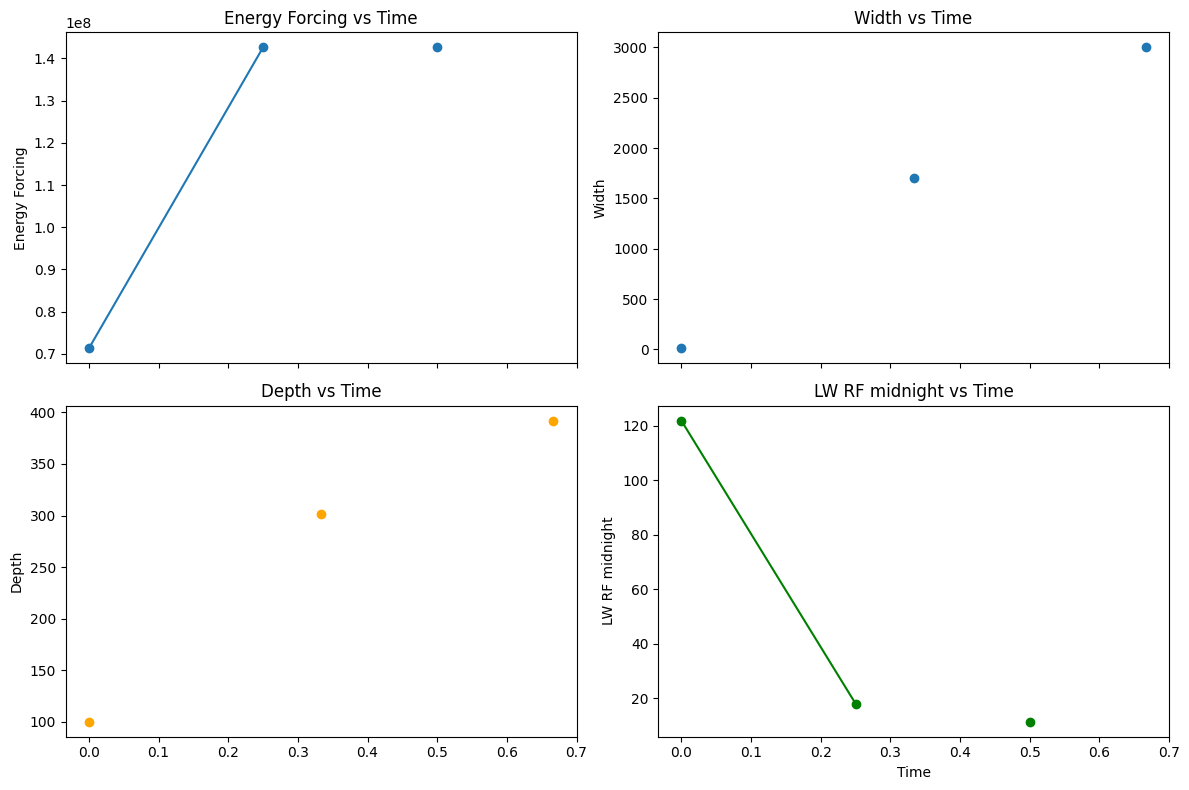

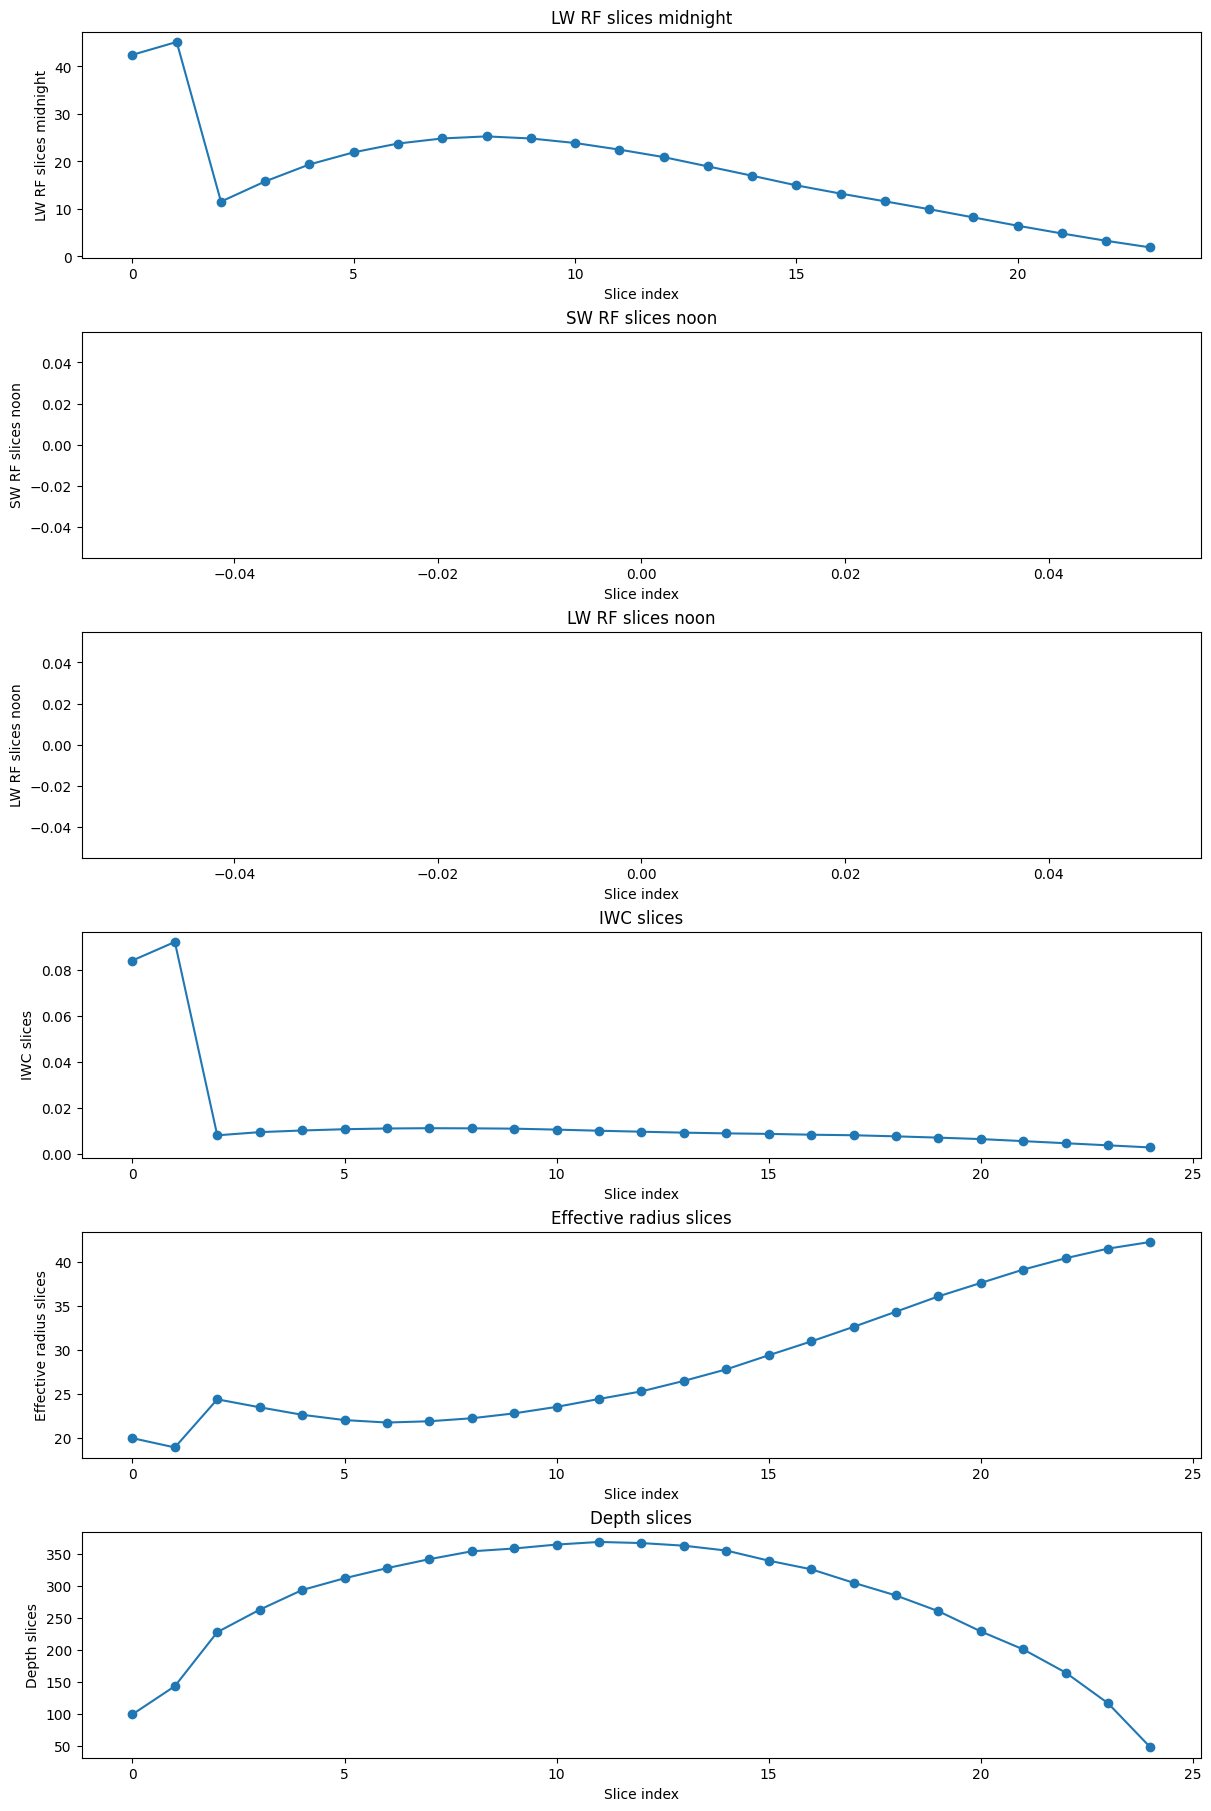

In [8]:
# Plot time series
time = test["t"].values

def pick_var(ds, candidates):
    for name in candidates:
        if name in ds:
            return ds[name]
    raise KeyError(f"None of these variables were found: {candidates}")

energy = pick_var(test, ["Energy Forcing"])
width  = pick_var(test, ["width", "Width"])
depth  = pick_var(test, ["depth", "Depth"])
lw_mid = pick_var(test, ["LW RF midnight"])

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()

ax[0].plot(time, energy.values, marker="o")
ax[0].set_title("Energy Forcing vs Time")
ax[0].set_ylabel("Energy Forcing")

ax[1].plot(time, width.values, marker="o")
ax[1].set_title("Width vs Time")
ax[1].set_ylabel("Width")

ax[2].plot(time, depth.values, marker="o", color="orange")
ax[2].set_title("Depth vs Time")
ax[2].set_ylabel("Depth")

ax[3].plot(time, lw_mid.values, marker="o", color="green")
ax[3].set_title("LW RF midnight vs Time")
ax[3].set_ylabel("LW RF midnight")
ax[3].set_xlabel("Time")

plt.tight_layout()

# Plot all variables containing "slices" vs slice index
slice_vars = [name for name in test.data_vars if "slices" in name.lower()]
n = len(slice_vars)

fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, name in zip(axes, slice_vars):
    da = test[name]
    if "slice" in da.dims:
        y = da.mean(dim=[d for d in da.dims if d != "slice"], skipna=True)
        ax.plot(test["slice"].values, y.values, marker="o")
        ax.set_xlabel("Slice index")
    else:
        ax.plot(np.arange(da.size), da.values, marker="o")
        ax.set_xlabel("Index")
    ax.set_title(name)
    ax.set_ylabel(name)

plt.show()